# 🖼️ Image Classification: CNN vs. ViT

**CO5085 – Assignment 1**

So sánh: **ResNet-50, EfficientNet-B0** (CNN) vs. **ViT-B/16** (Vision Transformer)

In [1]:
import sys, torch, os, json
sys.path.insert(0, '../src')
os.makedirs('../results', exist_ok=True)
DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

TRAIN_MODE = False  # False = load checkpoint (nhanh) | True = train lại từ đầu
print(f'Device: {DEVICE} | Train mode: {TRAIN_MODE}')

Device: mps | Train mode: False


## 1. Load Data

In [2]:
from datasets import get_cifar100_loaders
train_loader, val_loader, test_loader = get_cifar100_loaders(
    data_dir='../data/image', batch_size=128)
print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Train batches: 313 | Val: 79 | Test: 79


## 2. Model 1: ResNet-50 (CNN)

In [3]:
from models import get_resnet50

resnet = get_resnet50(num_classes=100, pretrained=TRAIN_MODE)
if TRAIN_MODE:
    from train import train
    history_resnet = train(resnet, train_loader, val_loader,
                           num_epochs=5, lr=1e-3, device=DEVICE,
                           save_path='../results/resnet50_best.pt', scheduler_type='cosine')
else:
    resnet.load_state_dict(torch.load('../results/resnet50_best.pt', map_location=DEVICE))
    with open('../results/resnet50_history.json') as f: history_resnet = json.load(f)
    print('ResNet-50 loaded ✅')
resnet = resnet.to(DEVICE).eval()

ResNet-50 loaded ✅


## 3. Model 2: EfficientNet-B0 (CNN)

In [4]:
from models import get_efficientnet_b0

effnet = get_efficientnet_b0(num_classes=100, pretrained=TRAIN_MODE)
if TRAIN_MODE:
    from train import train
    history_effnet = train(effnet, train_loader, val_loader,
                           num_epochs=5, lr=1e-3, device=DEVICE,
                           save_path='../results/efficientnet_best.pt')
else:
    effnet.load_state_dict(torch.load('../results/efficientnet_best.pt', map_location=DEVICE))
    with open('../results/efficientnet_history.json') as f: history_effnet = json.load(f)
    print('EfficientNet-B0 loaded ✅')
effnet = effnet.to(DEVICE).eval()

EfficientNet-B0 loaded ✅


## 4. Model 3: ViT-B/16

In [5]:
from models import get_vit_b16
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ViT needs 224x224
normalize = transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
val_tf = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor(), normalize])
test_ds_vit = datasets.CIFAR100('../data/image', train=False, download=False, transform=val_tf)
test_loader_vit = DataLoader(test_ds_vit, batch_size=32, shuffle=False, num_workers=0)

vit_model = get_vit_b16(num_classes=100, pretrained=TRAIN_MODE)
if TRAIN_MODE:
    from train import train
    train_tf = transforms.Compose([transforms.Resize(256), transforms.RandomCrop(224),
                                    transforms.RandomHorizontalFlip(), transforms.ToTensor(), normalize])
    train_ds_vit = datasets.CIFAR100('../data/image', train=True, download=False, transform=train_tf)
    val_size = int(0.2 * len(train_ds_vit))
    train_ds_vit, val_ds_vit = torch.utils.data.random_split(
        train_ds_vit, [len(train_ds_vit)-val_size, val_size],
        generator=torch.Generator().manual_seed(42))
    train_loader_vit = DataLoader(train_ds_vit, batch_size=32, shuffle=True, num_workers=0)
    val_loader_vit   = DataLoader(val_ds_vit,   batch_size=32, shuffle=False, num_workers=0)
    history_vit = train(vit_model, train_loader_vit, val_loader_vit,
                        num_epochs=5, lr=2e-5, device=DEVICE,
                        save_path='../results/vit_b16_best.pt', scheduler_type='cosine')
else:
    vit_model.load_state_dict(torch.load('../results/vit_b16_best.pt', map_location=DEVICE))
    hist_path = '../results/vit_b16_history.json'
    history_vit = json.load(open(hist_path)) if os.path.exists(hist_path) else {'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[]}
    print('ViT-B/16 loaded ✅' + ('' if os.path.exists(hist_path) else ' (no history file)'))
vit_model = vit_model.to(DEVICE).eval()

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ViT-B/16 loaded ✅ (no history file)


## 5. Evaluation & Comparison


=== ResNet-50 ===


/Users/ntphong8/Public/paul-private/hcmut-deeplearning-ass1/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Predicting:   0%|          | 0/79 [00:02<?, ?it/s]

Accuracy : 0.4411
F1-Macro : 0.4340

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.77      0.70       100
           1       0.48      0.57      0.52       100
           2       0.33      0.39      0.36       100
           3       0.16      0.20      0.18       100
           4       0.21      0.10      0.14       100
           5       0.31      0.33      0.32       100
           6       0.38      0.48      0.42       100
           7       0.66      0.47      0.55       100
           8       0.63      0.48      0.55       100
           9       0.54      0.49      0.51       100
          10       0.25      0.20      0.22       100
          11       0.31      0.27      0.29       100
          12       0.59      0.36      0.45       100
          13       0.45      0.37      0.41       100
          14       0.41      0.36      0.39       100
          15       0.32      0.27      0.29       100
          16       0.

Training curves saved → ../results/ResNet-50_curves.png


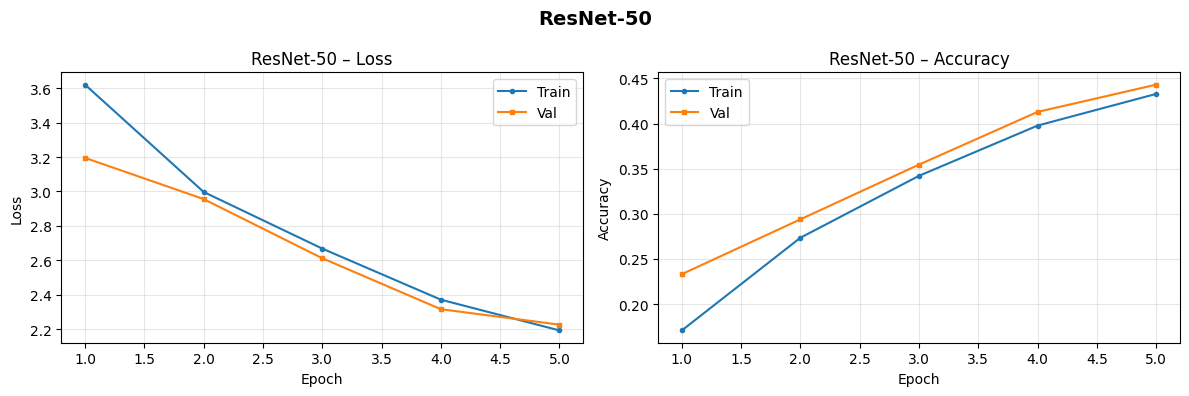


=== EfficientNet-B0 ===


/Users/ntphong8/Public/paul-private/hcmut-deeplearning-ass1/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Predicting:   0%|          | 0/79 [00:02<?, ?it/s]

Accuracy : 0.4555
F1-Macro : 0.4483

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.80      0.72       100
           1       0.46      0.57      0.51       100
           2       0.40      0.44      0.42       100
           3       0.21      0.12      0.15       100
           4       0.22      0.19      0.20       100
           5       0.34      0.21      0.26       100
           6       0.40      0.51      0.45       100
           7       0.59      0.43      0.50       100
           8       0.58      0.47      0.52       100
           9       0.47      0.42      0.44       100
          10       0.27      0.16      0.20       100
          11       0.29      0.23      0.26       100
          12       0.60      0.52      0.56       100
          13       0.39      0.37      0.38       100
          14       0.52      0.33      0.40       100
          15       0.36      0.38      0.37       100
          16       0.

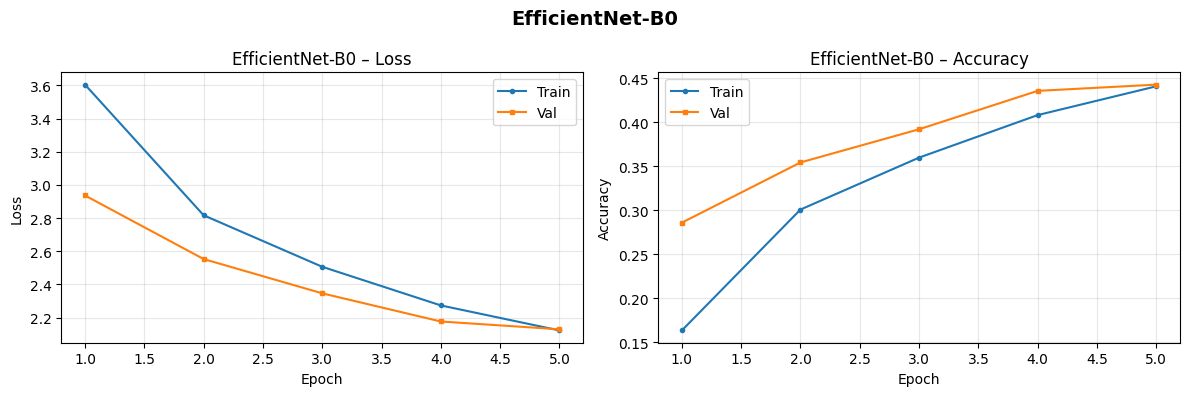


=== ViT-B/16 ===


Predicting:   0%|          | 0/313 [00:00<?, ?it/s]

Accuracy : 0.8960
F1-Macro : 0.8959

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       100
           1       0.93      0.97      0.95       100
           2       0.80      0.87      0.83       100
           3       0.87      0.90      0.89       100
           4       0.84      0.92      0.88       100
           5       0.87      0.97      0.92       100
           6       0.99      0.95      0.97       100
           7       0.90      0.94      0.92       100
           8       0.98      0.94      0.96       100
           9       0.97      0.98      0.98       100
          10       0.90      0.66      0.76       100
          11       0.69      0.61      0.65       100
          12       0.95      0.94      0.94       100
          13       0.96      0.79      0.87       100
          14       0.99      0.94      0.96       100
          15       0.98      0.96      0.97       100
          16       0.

Training curves saved → ../results/ViT-B/16_curves.png


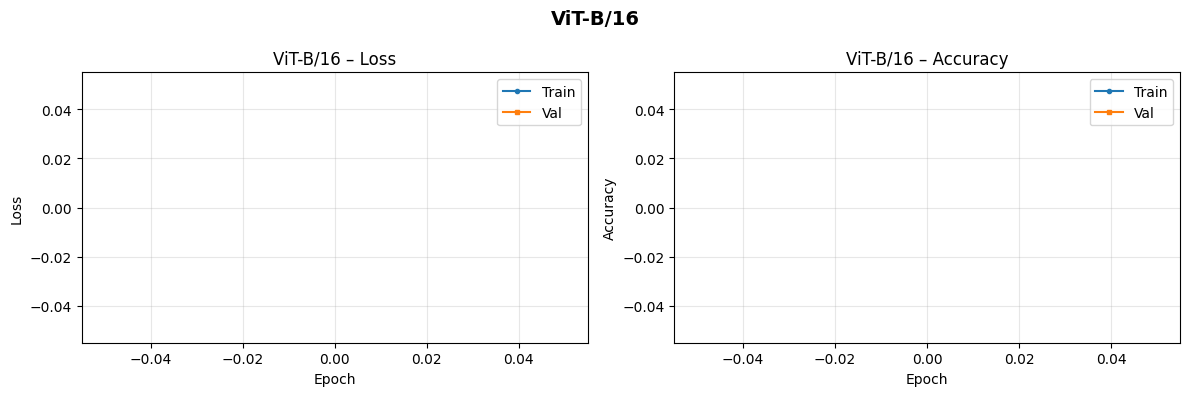

In [6]:
from evaluate import get_predictions, compute_metrics, plot_training_curves, compare_models
import torch

results = {}
for model_name, model, hist, loader in [
    ('ResNet-50',       resnet,      history_resnet, test_loader),
    ('EfficientNet-B0', effnet,      history_effnet, test_loader),
    ('ViT-B/16',        vit_model,   history_vit,    test_loader_vit),
]:
    print(f'\n=== {model_name} ===')
    preds, labels, probs = get_predictions(model, loader, DEVICE)
    results[model_name] = compute_metrics(preds, labels, verbose=True)
    plot_training_curves(hist, model_name=model_name, save_path=f'../results/{model_name}_curves.png')

## 6. Overall Comparison Chart

Comparison chart saved → ../results/image_comparison_acc.png


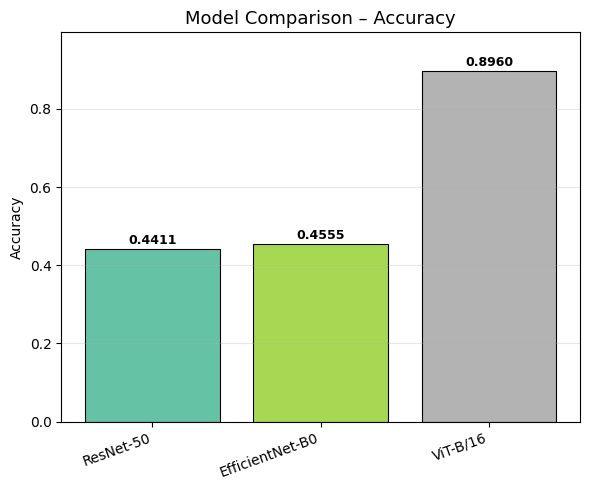

Comparison chart saved → ../results/image_comparison_f1.png


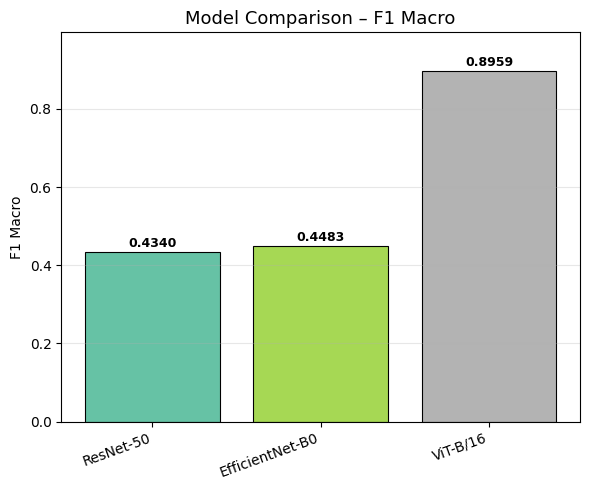

In [7]:
from evaluate import compare_models
compare_models(results, metric='accuracy', save_path='../results/image_comparison_acc.png')
compare_models(results, metric='f1_macro', save_path='../results/image_comparison_f1.png')